### Kalman Smoother

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
C:\Users\othma\AppData\Local\Temp\ipykernel_24072\967670478.py:4: SyntaxWarning: invalid escape sequence '\h'
  """


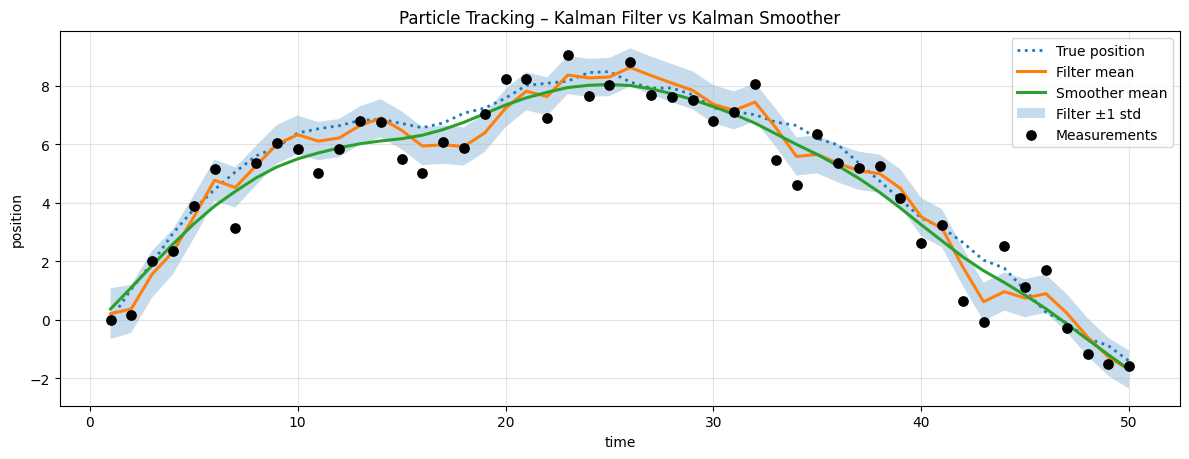

In [9]:
# Kalman Smoother

def kalman_smoother(F, m_pred, C_pred, m_filt, C_filt):
    """
    Kalman smoother 

    Inputs:
      m_pred[t] = \hat{m}, C_pred[t] = \hat{C}
      m_filt[t] = m_t,   C_filt[t] = C_t
    Outputs:
      m_smooth[t] = m^s, C_smooth[t] = C^s
    """
    F = np.asarray(F, dtype=float)
    T, n = m_filt.shape

    m_smooth = np.zeros_like(m_filt)
    C_smooth = np.zeros_like(C_filt)

    # final time: smoothed = filtered
    m_smooth[-1] = m_filt[-1]
    C_smooth[-1] = C_filt[-1]

    # backward pass
    for t in range(T - 2, -1, -1):
        # C_pred[t+1] is C_{t+1|t}
        J = C_filt[t] @ F.T @ np.linalg.solve(C_pred[t + 1], np.eye(n))
        m_smooth[t] = m_filt[t] + J @ (m_smooth[t + 1] - m_pred[t + 1])
        C_smooth[t] = C_filt[t] + J @ (C_smooth[t + 1] - C_pred[t + 1]) @ J.T

    return m_smooth, C_smooth


m_pred = out["m_hat"]
C_pred = out["C_hat"]

m_smooth, C_smooth = kalman_smoother(F, m_pred, C_pred, m_filt, C_filt)

# Extract position series
tgrid = np.arange(1, T + 1)

true_pos = zs[:, 0]
meas_pos = xs[:, 0]

filt_pos = m_filt[:, 0]
smooth_pos = m_smooth[:, 0]

# Kalman Filter confidence interval (±1 std on position)
filt_pos_std = np.sqrt(C_filt[:, 0, 0])


# Plot

plt.figure(figsize=(12, 4.7))
plt.title("Particle Tracking – Kalman Filter vs Kalman Smoother")

plt.plot(tgrid, true_pos, linestyle=":", linewidth=2.0, label="True position")
plt.plot(tgrid, filt_pos, linewidth=2.2, label="Filter mean")
plt.plot(tgrid, smooth_pos, linewidth=2.2, label="Smoother mean")

plt.fill_between(
    tgrid,
    filt_pos - filt_pos_std,
    filt_pos + filt_pos_std,
    alpha=0.25,
    label="Filter ±1 std"
)

plt.scatter(
    tgrid,
    meas_pos,
    s=45,
    color="black",
    zorder=5,
    label="Measurements"
)

plt.xlabel("time")
plt.ylabel("position")
plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
C:\Users\othma\AppData\Local\Temp\ipykernel_24072\1709346760.py:19: SyntaxWarning: invalid escape sequence '\s'
  label="Filter ±1 $\sigma$ "
C:\Users\othma\AppData\Local\Temp\ipykernel_24072\1709346760.py:28: SyntaxWarning: invalid escape sequence '\s'
  label="Smoother ±1 $\sigma$"


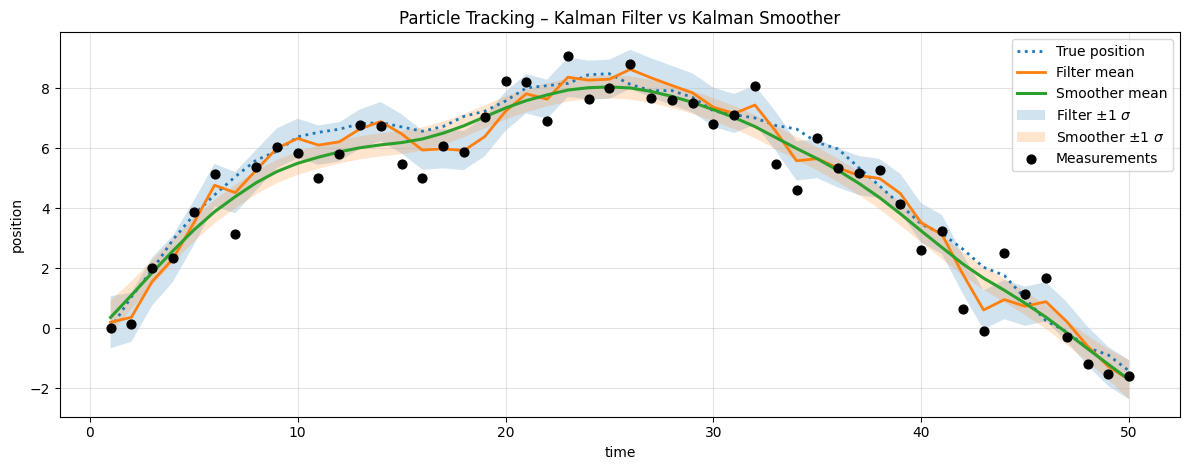

In [10]:
# Plot 1: filter vs smoother with uncertainty bands

filt_pos_std = np.sqrt(C_filt[:, 0, 0])
smooth_pos_std = np.sqrt(C_smooth[:, 0, 0])

plt.figure(figsize=(12, 4.8))
plt.title("Particle Tracking – Kalman Filter vs Kalman Smoother")

plt.plot(tgrid, true_pos, linestyle=":", linewidth=2.0, label="True position")
plt.plot(tgrid, filt_pos, linewidth=2.0, label="Filter mean")
plt.plot(tgrid, smooth_pos, linewidth=2.2, label="Smoother mean")

# Filter uncertainty
plt.fill_between(
    tgrid,
    filt_pos - filt_pos_std,
    filt_pos + filt_pos_std,
    alpha=0.20,
    label="Filter ±1 $\sigma$ "
)

# Smoother uncertainty
plt.fill_between(
    tgrid,
    smooth_pos - smooth_pos_std,
    smooth_pos + smooth_pos_std,
    alpha=0.20,
    label="Smoother ±1 $\sigma$"
)

plt.scatter(
    tgrid,
    meas_pos,
    s=40,
    color="black",
    zorder=5,
    label="Measurements"
)

plt.xlabel("time")
plt.ylabel("position")
plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

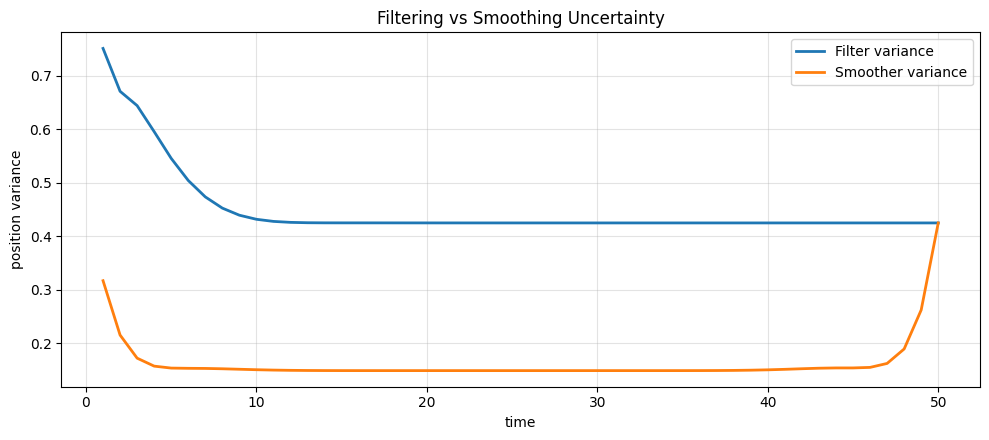

In [11]:
# Plot 2: filtering vs smoothing uncertainty over time

plt.figure(figsize=(10, 4.5))
plt.plot(tgrid, C_filt[:, 0, 0], linewidth=2.0, label="Filter variance")
plt.plot(tgrid, C_smooth[:, 0, 0], linewidth=2.0, label="Smoother variance")

plt.xlabel("time")
plt.ylabel("position variance")
plt.title("Filtering vs Smoothing Uncertainty")
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

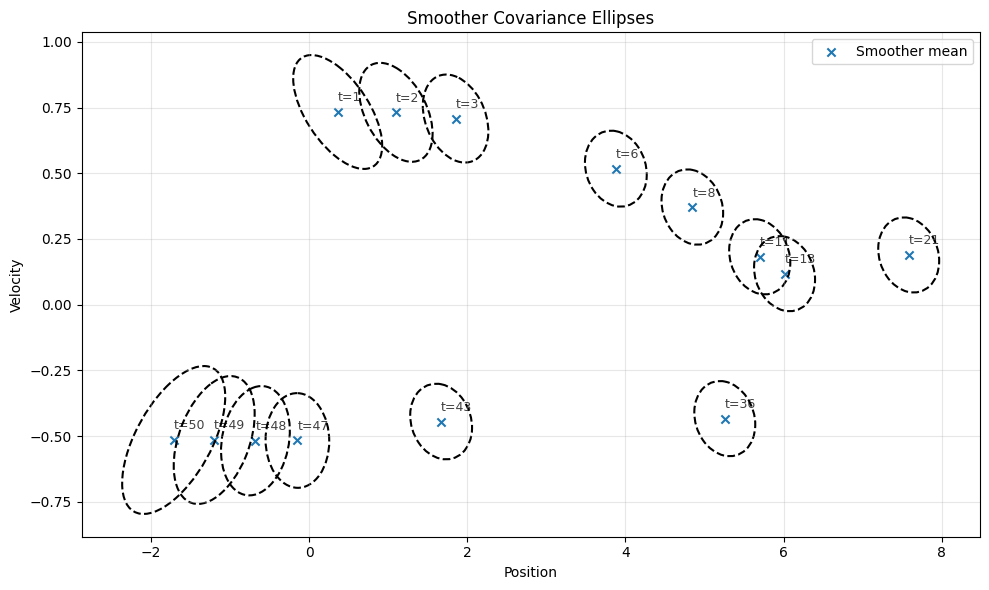

In [12]:
# Plot 3: filter and smoother covariance ellipses in (position, velocity) space

from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_title("Smoother Covariance Ellipses")
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.grid(True, alpha=0.3)

# Select a few times to avoid clutter
steps = [0, 1, 2, 5, 7, 10, 12, 20, T-15, T-8, T-4, T-3, T-2, T - 1]

# Means at selected times
ax.scatter(m_smooth[steps, 0], m_smooth[steps, 1], s=35, marker="x", label="Smoother mean")

for t in steps:
    # # --- Filter ellipse ---
    # mean_f = m_filt[t]
    # cov_f = C_filt[t]

    # vals_f, vecs_f = np.linalg.eigh(cov_f)
    # order_f = vals_f.argsort()[::-1]
    # vals_f = vals_f[order_f]
    # vecs_f = vecs_f[:, order_f]

    # angle_f = np.degrees(np.arctan2(vecs_f[1, 0], vecs_f[0, 0]))
    # width_f, height_f = 2 * np.sqrt(vals_f)

    # ell_f = Ellipse(
    #     xy=mean_f,
    #     width=width_f,
    #     height=height_f,
    #     angle=angle_f,  
    #     fill=False,
    #     lw=1.5,
    # )
    # ax.add_patch(ell_f)

    # --- Smoother ellipse ---
    mean_s = m_smooth[t]
    cov_s = C_smooth[t]

    vals_s, vecs_s = np.linalg.eigh(cov_s)
    order_s = vals_s.argsort()[::-1]
    vals_s = vals_s[order_s]
    vecs_s = vecs_s[:, order_s]

    angle_s = np.degrees(np.arctan2(vecs_s[1, 0], vecs_s[0, 0]))
    width_s, height_s = 2 * np.sqrt(vals_s)

    ell_s = Ellipse(
        xy=mean_s,
        width=width_s,
        height=height_s,
        angle=angle_s,
        fill=False,
        lw=1.5,
        linestyle="--"
    )
    ax.add_patch(ell_s)

    # Label the time once near the smoother mean
    ax.text(mean_s[0], mean_s[1] + 0.04, f"t={t+1}", fontsize=9, alpha=0.75)

plt.legend()
plt.tight_layout()
plt.show()